In [1]:
import numpy as np
import pandas as pd
import os, re, math, platform
from pathlib import Path
import matplotlib.pyplot as plt
import json
import joblib
from scipy.stats import randint as sp_randint
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import RandomizedSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import matthews_corrcoef, confusion_matrix
from sklearn.metrics import precision_recall_curve, roc_curve, auc, fbeta_score
from imblearn.metrics import geometric_mean_score
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier 
from xgboost import plot_importance
from sklearn.ensemble import GradientBoostingClassifier,RandomForestClassifier,ExtraTreesClassifier,AdaBoostClassifier
from sklearn.linear_model import SGDClassifier
#from sklearn.linear_model import ElasticNet
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from Bio import SeqIO
from Bio.SeqUtils.ProtParam import ProteinAnalysis as PA
from modlamp.descriptors import PeptideDescriptor, GlobalDescriptor
from matplotlib import pyplot
from sklearn.metrics import matthews_corrcoef, confusion_matrix,precision_recall_curve, roc_curve, auc, fbeta_score,roc_auc_score
from fea_extract import read_fasta,insert_AAC,insert_DPC,insert_CKSAAGP,insert_CTD,insert_PAAC,insert_AAI,insert_GTPC,insert_QSO,insert_AAE,insert_PSAAC,insert_word2int,insert_ASDC
import warnings 
from collections import Counter
from tools import cv,evaluate
import matplotlib.pyplot as plt
import seaborn as sns
Path('./results/balance_eval_AUC/').mkdir(exist_ok=True,parents=True)
warnings.filterwarnings('ignore')
seed=10

In [2]:
#!pip install lightgbm
from sklearn.ensemble import BaggingClassifier

In [3]:
def pro_data(seq):
    df_n = insert_PAAC(seq)
    df_n = insert_AAC(df_n)
    df_n = insert_CKSAAGP(df_n)
    df_n = insert_CTD(df_n)
    df_n = insert_DPC(df_n)
    df_n = insert_GTPC(df_n)
    df_n = insert_QSO(df_n)
    df_n = insert_AAE(df_n)
    df_n = insert_ASDC(df_n)
    #df_n = insert_word2int(df_n)
    return df_n

In [4]:
seq_X_train = pd.read_csv('data/train/X_train.csv')
seq_X_test = pd.read_csv('data/test/X_test.csv')
seq_y_train = pd.read_csv('data/train/y_train.csv')
seq_y_test = pd.read_csv('data/test/y_test.csv')

In [5]:
Seq_X_train = pro_data(seq_X_train)
Seq_X_test = pro_data(seq_X_test)

In [6]:
Seq_X_train

,Id,Sequence,Xc1.A,Xc1.R,Xc1.N,Xc1.D,Xc1.C,Xc1.Q,Xc1.E,Xc1.G,...,ASDC_390,ASDC_391,ASDC_392,ASDC_393,ASDC_394,ASDC_395,ASDC_396,ASDC_397,ASDC_398,ASDC_399
0,Sequence_51,GLFDVIKKVASVIKGL,0.270187,0.000000,0.000000,0.270187,0.000000,0.000000,0.000000,0.540375,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,Sequence_146,GLPVCGETCVGGTCNTPGCGCSWPVCTRN,0.000000,0.409796,0.819591,0.000000,2.458773,0.000000,0.409796,2.458773,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,Sequence_259,GMWKKILGHLIR,0.000000,0.208361,0.000000,0.000000,0.000000,0.000000,0.000000,0.416722,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,Sequence_313,YGRKKRRQRRRREADFFWSLCTADMS,0.619674,2.168859,0.000000,0.619674,0.309837,0.309837,0.309837,0.309837,...,0.003077,0.000000,0.000000,0.003077,0.021538,0.006154,0.003077,0.000000,0.003077,0.000000
4,Sequence_53,CSCRTSSCRFGERLSGACRLNGRIYRLCC,0.214105,1.284629,0.214105,0.000000,1.284629,0.000000,0.214105,0.642314,...,0.000000,0.000000,0.000000,0.000000,0.002463,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1515,Sequence_377,VEKAGIQDVLTKSWGSSNPVNIVKATLDALEQLETPILAAKKRGISLN,1.465278,0.293056,0.879167,0.586111,0.000000,0.586111,0.879167,0.879167,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1516,Sequence_328,CYGSETIDMDPTRPKAIWGFNGTERPGAV,0.545697,0.545697,0.272849,0.545697,0.272849,0.000000,0.545697,1.091395,...,0.002463,0.002463,0.007389,0.000000,0.004926,0.002463,0.007389,0.002463,0.002463,0.000000
1517,Sequence_537,YFKAIGVLLATCIIGFYVLTQLLSILANWWISIWTNSYGGNGNGSGS,1.076551,0.000000,1.435401,0.000000,0.358850,0.358850,0.000000,2.511951,...,0.000000,0.009251,0.000000,0.001850,0.000000,0.011101,0.004625,0.002775,0.005550,0.002775
1518,Sequence_129,YSGDDAYATDAILNS,0.901273,0.000000,0.300424,0.901273,0.000000,0.000000,0.000000,0.300424,...,0.000000,0.019048,0.000000,0.000000,0.000000,0.028571,0.019048,0.000000,0.000000,0.009524


In [7]:
Seq_X_train.to_csv('data/train/Seq_X_train_all.csv',index=False)
Seq_X_test.to_csv('data/test/Seq_X_test_all.csv',index=False)

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from mlxtend.classifier import StackingClassifier

from sklearn.svm import LinearSVC

ml = ["DT","LGBM","XGBoost","RF","ET","GBDT","SVM","MLP","LR","AB","voting_clf","stacking","Two_eclf"]

layer_one= [  LGBMClassifier(random_state = seed),ExtraTreesClassifier(random_state=seed),RandomForestClassifier(random_state=seed),MLPClassifier(hidden_layer_sizes=700,learning_rate="adaptive",random_state=seed)]
                     #('rf5',GaussianNB()),
#                   ('SVM', SVC(kernel='linear',probability=True))]
layer_two = [SVC(random_state=seed,probability=True), ExtraTreesClassifier(random_state=seed),RandomForestClassifier(random_state=seed),LGBMClassifier(random_state = seed)]
             #GaussianNB()]
#                   ('SVC', SVC(kernel='linear',probability=True))]

layer_two_meta= StackingClassifier(classifiers = layer_two, meta_classifier=LogisticRegression())    
DT  = DecisionTreeClassifier(random_state=seed)
LGBM = LGBMClassifier(random_state = seed)
GBDT = GradientBoostingClassifier(random_state=seed)
ET = ExtraTreesClassifier(random_state=seed)
SVM = SVC(random_state=seed,probability=True)
MLP = MLPClassifier(hidden_layer_sizes=700,learning_rate="adaptive",random_state=seed)
RF = RandomForestClassifier(random_state=seed)
XGBoost = XGBClassifier(random_state=seed)
LR  = LogisticRegression(random_state=seed,solver='liblinear')
AB = AdaBoostClassifier(random_state=seed)
#SDG_Classifier = SGDClassifier(max_iter=1000, tol=1e-3) 
voting_clf = VotingClassifier(estimators = [('lgbm',LGBM),('rf',RF),('xgb',XGBoost),('ET',ET),('GBDT',GBDT)], voting = 'soft')
Bagging_clf = BaggingClassifier(base_estimator=RandomForestClassifier(random_state=seed))
#VOT_STACK = StackingClassifier(classifiers = voting_clf, meta_classifier=LR)
stacking = StackingClassifier(classifiers=[LGBM,RF,XGBoost,ET, GBDT],meta_classifier=LR)
Two_eclf = StackingClassifier(classifiers=layer_one, meta_classifier=layer_two_meta)

In [9]:
fea = Seq_X_train.columns[2:]
X_train = Seq_X_train[fea].to_numpy()
X_test = Seq_X_test[fea].to_numpy()
y_train = seq_y_train.to_numpy()
y_test = seq_y_test.to_numpy()

In [10]:
len(fea)

1296

In [11]:
index = []
ALL_eval=pd.DataFrame()
for i in ml:
    print('process_{}'.format(i))
    model = eval(i)
    Evals = cv(model,X_train,y_train)
    ALL_eval = pd.concat([ALL_eval,Evals],axis=1)
    index.append("{}".format(i))
ALL_eval.columns = index

process_DT
process_LGBM
[LightGBM] [Info] Number of positive: 608, number of negative: 608
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.052563 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 100151
[LightGBM] [Info] Number of data points in the train set: 1216, number of used features: 1246
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 625, number of negative: 591
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.038285 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 98953
[LightGBM] [Info] Number of data points in the train set: 1216, number of used features: 1240
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.513980 -> initscore=0.055936
[LightGBM] [Info] St

In [12]:
ALL_eval

,DT,LGBM,XGBoost,RF,ET,GBDT,SVM,MLP,LR,AB,voting_clf,stacking,Two_eclf
ACC,0.853947,0.917763,0.925000,0.917105,0.925000,0.910526,0.904605,0.920395,0.899342,0.884211,0.926316,0.926316,0.924342
F1,0.856510,0.915817,0.923903,0.914570,0.921806,0.908757,0.903014,0.919995,0.897446,0.883198,0.924221,0.923997,0.921914
F2,0.866690,0.905507,0.918263,0.900209,0.902849,0.900191,0.894286,0.919636,0.891562,0.880529,0.911285,0.910244,0.907120
GMean,0.853921,0.917677,0.925228,0.917136,0.924550,0.910500,0.904789,0.920088,0.899115,0.884221,0.926529,0.926255,0.924348
SEN,0.873729,0.898970,0.914645,0.891006,0.890711,0.894618,0.888632,0.919466,0.887733,0.878803,0.903008,0.901437,0.897633
PREC,0.840459,0.934447,0.933894,0.940122,0.955588,0.923619,0.918248,0.920877,0.907648,0.887869,0.947293,0.948495,0.948206
SPEC,0.834681,0.937357,0.936165,0.944308,0.959866,0.926784,0.921349,0.920949,0.910809,0.889752,0.951001,0.952116,0.952123
MCC,0.708475,0.836881,0.850441,0.835737,0.852006,0.821340,0.809677,0.840686,0.798599,0.768179,0.854142,0.854124,0.850256
AUC,0.854205,0.977000,0.976182,0.973476,0.976824,0.970654,0.961989,0.973292,0.957957,0.951364,0.977934,0.948581,0.939091
AUPR,0.797828,0.979715,0.979759,0.976709,0.980065,0.975005,0.965240,0.976802,0.960457,0.954039,0.981119,0.938894,0.922552


In [13]:
index = []
ALL_eval_test=pd.DataFrame()
for i in ml:
    eval_dict = []
    print('process_{}'.format(i))
    model = eval(i)
    model.fit(X_train,y_train)
    eval_dictionary = evaluate(X_test,y_test,model)
    eval_dict = eval_dict+[eval_dictionary]
    Evals = pd.DataFrame(eval_dict).T
    ALL_eval_test = pd.concat([ALL_eval_test,Evals],axis=1)
    index.append("{}".format(i))
ALL_eval_test.columns = index

process_DT
process_LGBM
[LightGBM] [Info] Number of positive: 763, number of negative: 757
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.039076 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 112772
[LightGBM] [Info] Number of data points in the train set: 1520, number of used features: 1260
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.501974 -> initscore=0.007895
[LightGBM] [Info] Start training from score 0.007895
process_XGBoost
process_RF
process_ET
process_GBDT
process_SVM
process_MLP
process_LR
process_AB
process_voting_clf
[LightGBM] [Info] Number of positive: 763, number of negative: 757
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.048221 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 112772
[LightGBM] [Info] Number of data points in the train set: 1520, number of used features: 1260
[Lig

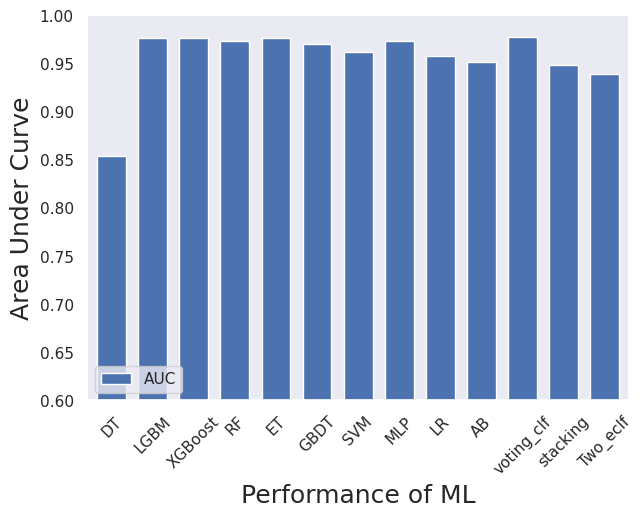

In [14]:
evals = ALL_eval.loc[['AUC'],:]
sns.set()
evals.T.plot.bar(figsize=(7,5),rot=45,width = 0.7,grid = False)
plt.ylim(0.6,1.0)
plt.ylabel('Area Under Curve',fontsize=18)
plt.xlabel('Performance of ML',fontsize=18)
plt.legend(loc =  'lower left' )

In [15]:
ALL_eval_test

,DT,LGBM,XGBoost,RF,ET,GBDT,SVM,MLP,LR,AB,voting_clf,stacking,Two_eclf
ACC,0.858268,0.916010,0.902887,0.897638,0.902887,0.895013,0.895013,0.910761,0.910761,0.879265,0.905512,0.902887,0.913386
F1,0.860104,0.914439,0.901857,0.896552,0.899729,0.894180,0.893048,0.909574,0.910526,0.878307,0.903743,0.901333,0.912467
F2,0.865485,0.902851,0.894737,0.889474,0.881104,0.888538,0.881732,0.900948,0.907660,0.872766,0.892291,0.891350,0.905263
GMean,0.858170,0.915829,0.902829,0.897579,0.902341,0.894982,0.894828,0.910670,0.910761,0.879233,0.905329,0.902753,0.913329
SEN,0.869110,0.895288,0.890052,0.884817,0.869110,0.884817,0.874346,0.895288,0.905759,0.869110,0.884817,0.884817,0.900524
PREC,0.851282,0.934426,0.913978,0.908602,0.932584,0.903743,0.912568,0.924324,0.915344,0.887701,0.923497,0.918478,0.924731
SPEC,0.847368,0.936842,0.915789,0.910526,0.936842,0.905263,0.915789,0.926316,0.915789,0.889474,0.926316,0.921053,0.926316
MCC,0.716676,0.832773,0.806064,0.795562,0.807690,0.790211,0.790745,0.821944,0.821571,0.758709,0.811759,0.806336,0.827067
AUC,0.858239,0.975971,0.975503,0.969454,0.971769,0.966823,0.960898,0.971342,0.965059,0.957785,0.973216,0.932351,0.926164
AUPR,0.805474,0.978489,0.977380,0.973017,0.976218,0.969767,0.964595,0.975442,0.969691,0.957045,0.977087,0.914788,0.903404


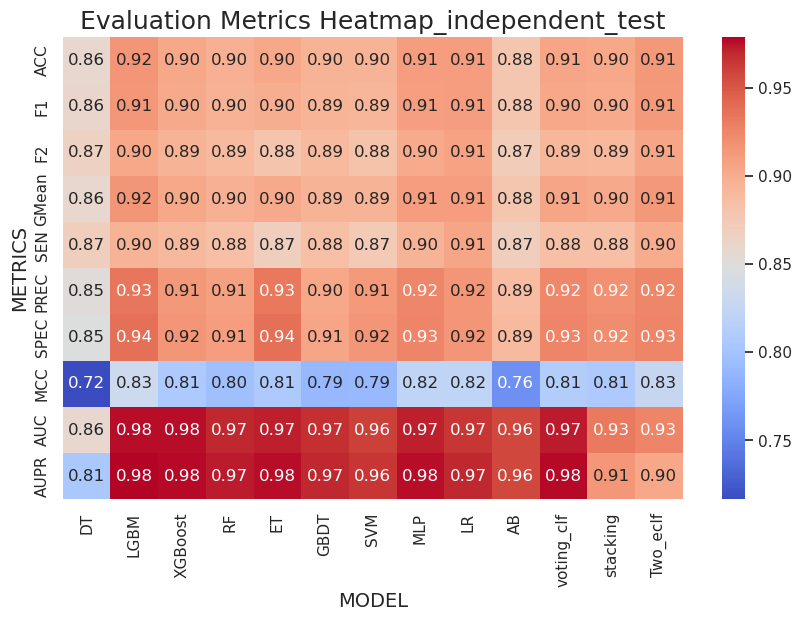

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming ALL_eval_test is a DataFrame with metrics as columns and models as rows

# Create a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(ALL_eval_test, cmap='coolwarm', annot=True, fmt=".2f", cbar=True)

plt.title('Evaluation Metrics Heatmap_independent_test', fontsize=18)
plt.xlabel('MODEL', fontsize=14)
plt.ylabel('METRICS',size=14)

plt.show()

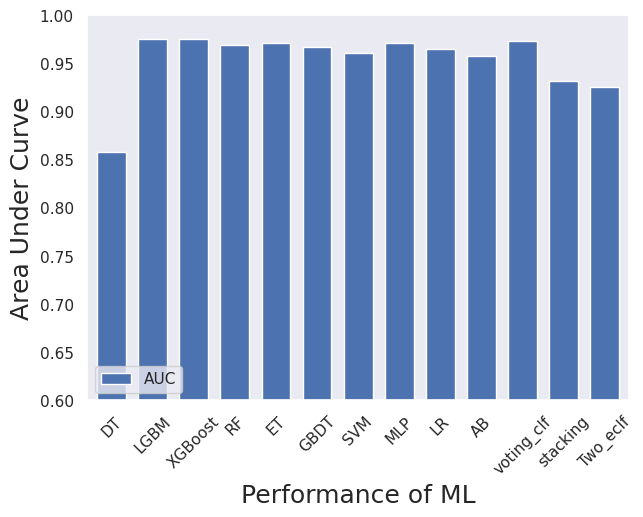

In [17]:
evals = ALL_eval_test.loc[['AUC'],:]
sns.set()
evals.T.plot.bar(figsize=(7,5),rot=45,width = 0.7,grid = False)
plt.ylim(0.6,1.0)
plt.ylabel('Area Under Curve',fontsize=18)
plt.xlabel('Performance of ML',fontsize=18)
plt.legend(loc =  'lower left' )

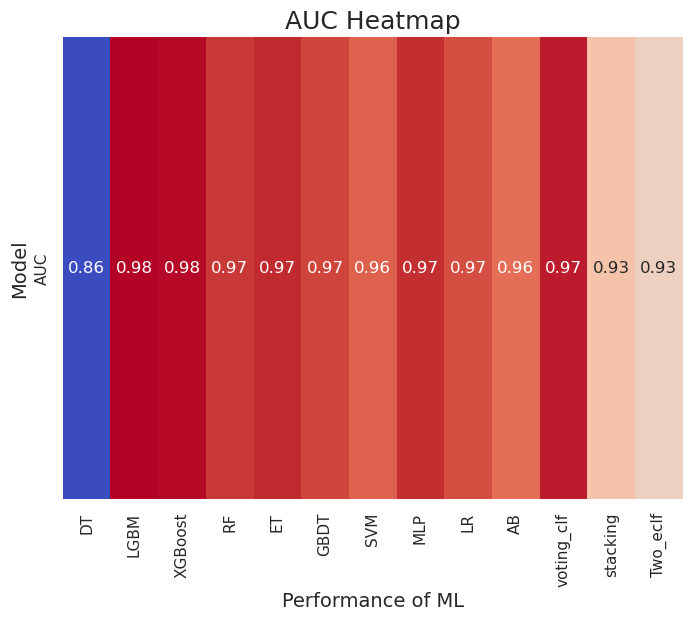

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming ALL_eval_test is a DataFrame containing AUC values
auc_data = ALL_eval_test.loc[['AUC'], :]

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(auc_data, cmap='coolwarm', annot=True, fmt=".2f", cbar=False)

plt.title('AUC Heatmap', fontsize=18)
plt.xlabel('Performance of ML', fontsize=14)
plt.ylabel('Model', fontsize=14)

plt.show()

In [19]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler 

In [20]:
#Scaling the train and test dataset for training
nms = MinMaxScaler()
X_train_norm = nms.fit_transform(X_train)
X_test_norm = nms.transform(X_test)
#standard scaling
stdsc = StandardScaler(with_mean=False)
X_train_std = stdsc.fit_transform(X_train)
X_test_std = stdsc.transform(X_test)

In [21]:
#Save the standarzied and normalixed data
X_train_norm1 = pd.DataFrame(X_train_norm)
X_train_norm1.to_csv('data/train/X_train_norm.csv',index=False)
X_test_norm1 = pd.DataFrame(X_test_norm)
X_test_norm1.to_csv('data/test/X_test_norm.csv',index=False)
#standarization
X_train_std1 = pd.DataFrame(X_train_std)
X_train_std1.to_csv('data/train/X_train_std.csv',index=False)
X_test_std1 = pd.DataFrame(X_test_std)
X_test_std1.to_csv('data/test/X_test_std.csv',index=False)

In [22]:
#performance of the model after standarization
#5 fold performance of the model
index = []
ALL_eval=pd.DataFrame()
for i in ml:
    print('process_{}'.format(i))
    model = eval(i)
    Evals = cv(model,X_train_std,y_train)
    ALL_eval = pd.concat([ALL_eval,Evals],axis=1)
    index.append("{}".format(i))
ALL_eval.columns = index

process_DT
process_LGBM
[LightGBM] [Info] Number of positive: 608, number of negative: 608
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.047800 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 100153
[LightGBM] [Info] Number of data points in the train set: 1216, number of used features: 1246
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 625, number of negative: 591
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.030745 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 98958
[LightGBM] [Info] Number of data points in the train set: 1216, number of used features: 1240
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.513980 -> initscore=0.055936
[LightGBM] [Info] St

In [23]:
ALL_eval

,DT,LGBM,XGBoost,RF,ET,GBDT,SVM,MLP,LR,AB,voting_clf,stacking,Two_eclf
ACC,0.853947,0.913158,0.925000,0.917763,0.924342,0.911842,0.921053,0.921053,0.910526,0.884868,0.925658,0.925000,0.923684
F1,0.856510,0.910832,0.923903,0.914939,0.921087,0.909864,0.916696,0.919167,0.908666,0.884740,0.923556,0.922762,0.921066
F2,0.866690,0.899545,0.918263,0.898045,0.901780,0.901475,0.891041,0.911213,0.902943,0.886586,0.910996,0.909106,0.905897
GMean,0.853921,0.913175,0.925228,0.917755,0.923879,0.912006,0.919848,0.920935,0.910209,0.884784,0.925770,0.925056,0.923700
SEN,0.873729,0.892373,0.914645,0.887231,0.889429,0.896169,0.874798,0.906085,0.899257,0.887869,0.903000,0.900402,0.896199
PREC,0.840459,0.931183,0.933894,0.945058,0.955549,0.925070,0.963314,0.933160,0.918736,0.881867,0.946132,0.947272,0.948162
SPEC,0.834681,0.934992,0.936165,0.949549,0.959866,0.928616,0.967492,0.936297,0.921583,0.881823,0.949585,0.950837,0.952362
MCC,0.708475,0.827768,0.850441,0.837456,0.850793,0.824785,0.845615,0.842529,0.821116,0.769456,0.852944,0.851734,0.849119
AUC,0.854205,0.976291,0.976182,0.973554,0.976889,0.971368,0.974560,0.968148,0.961168,0.951728,0.977630,0.947777,0.934080
AUPR,0.797828,0.978652,0.979759,0.976906,0.980117,0.975363,0.978688,0.973754,0.963298,0.954192,0.980852,0.938223,0.917485


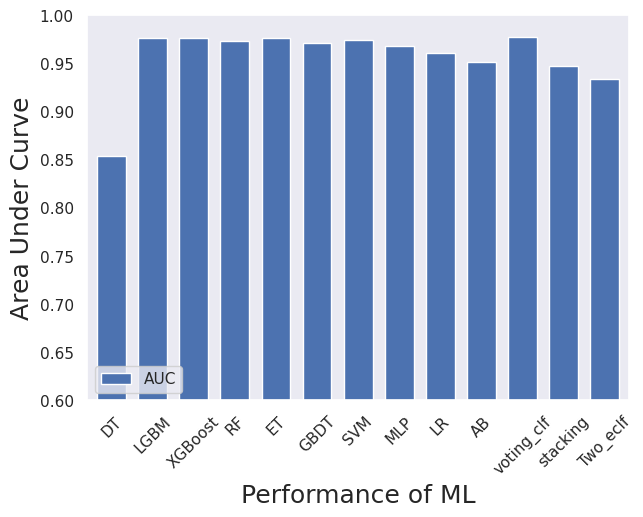

In [24]:
evals = ALL_eval.loc[['AUC'],:]
sns.set()
evals.T.plot.bar(figsize=(7,5),rot=45,width = 0.7,grid = False)
plt.ylim(0.6,1.0)
plt.ylabel('Area Under Curve',fontsize=18)
plt.xlabel('Performance of ML',fontsize=18)
plt.legend(loc =  'lower left' )

Processing SHAP for DT


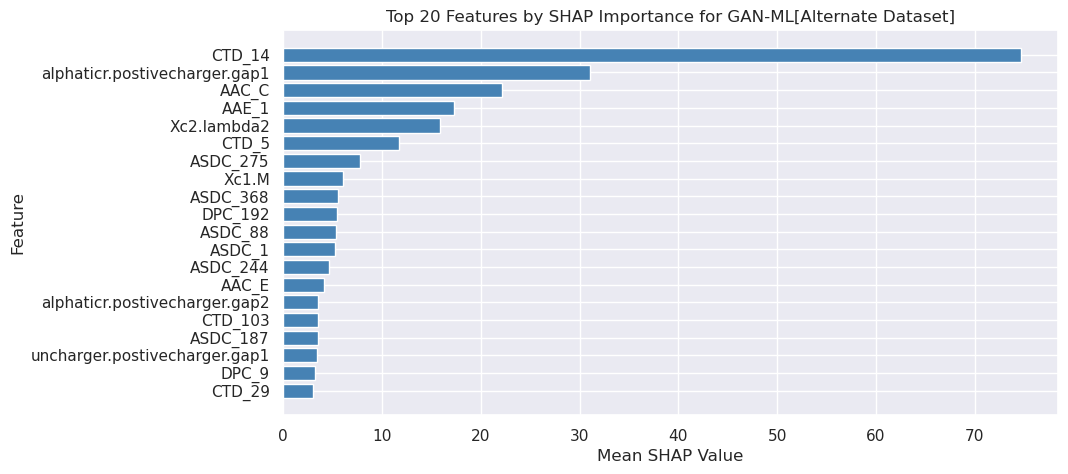

Processing SHAP for LGBM
[LightGBM] [Info] Number of positive: 763, number of negative: 757
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.033527 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 112773
[LightGBM] [Info] Number of data points in the train set: 1520, number of used features: 1260
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.501974 -> initscore=0.007895
[LightGBM] [Info] Start training from score 0.007895


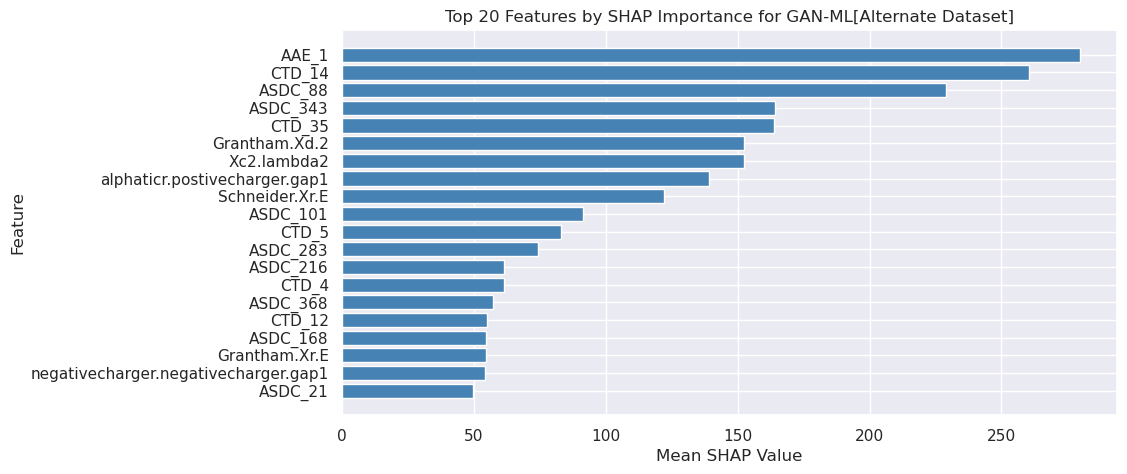

Processing SHAP for XGBoost


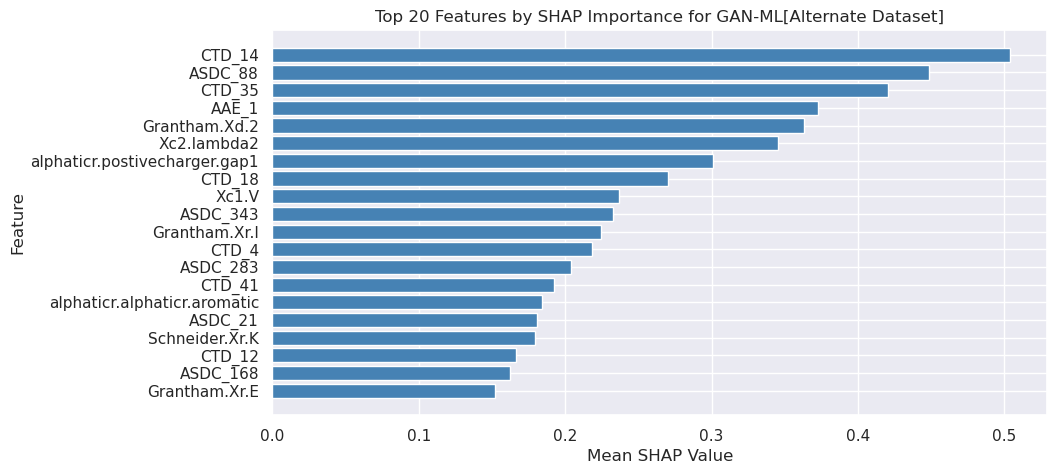

Processing SHAP for RF


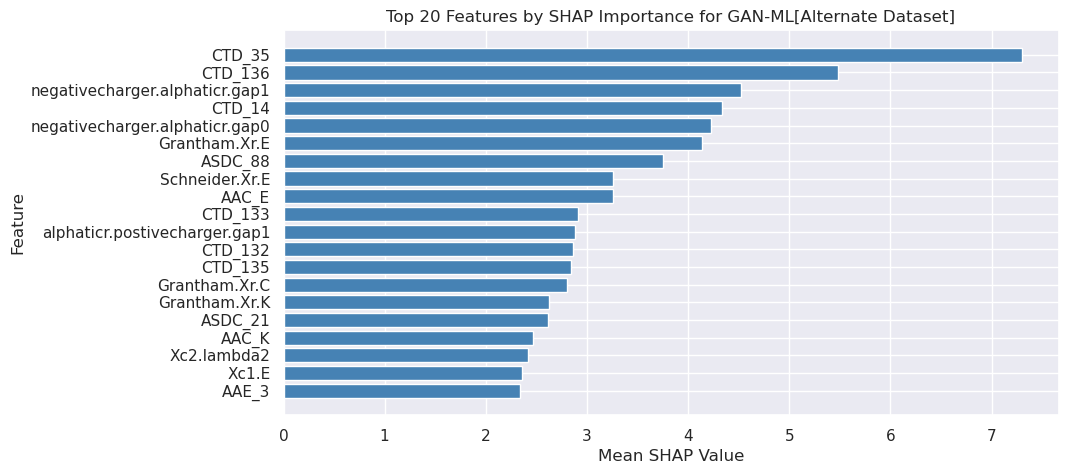

Processing SHAP for ET


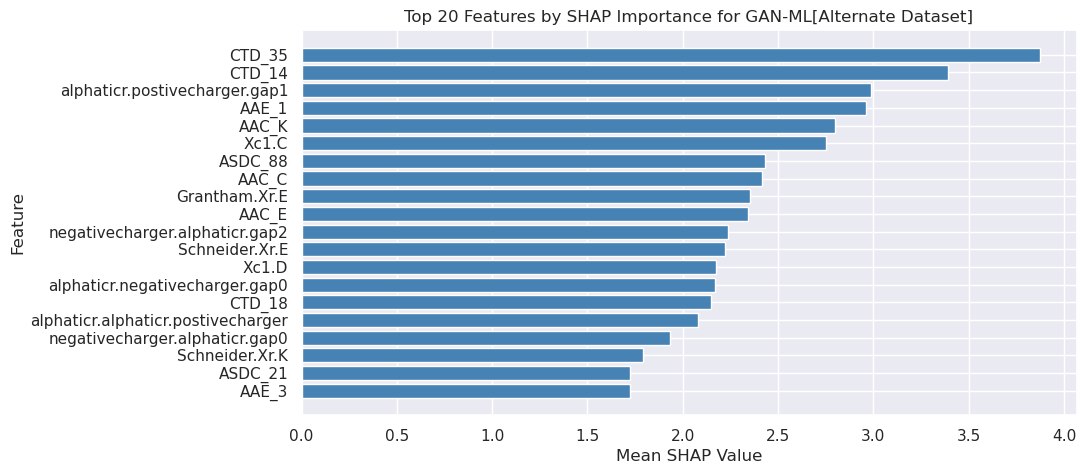

Processing SHAP for GBDT


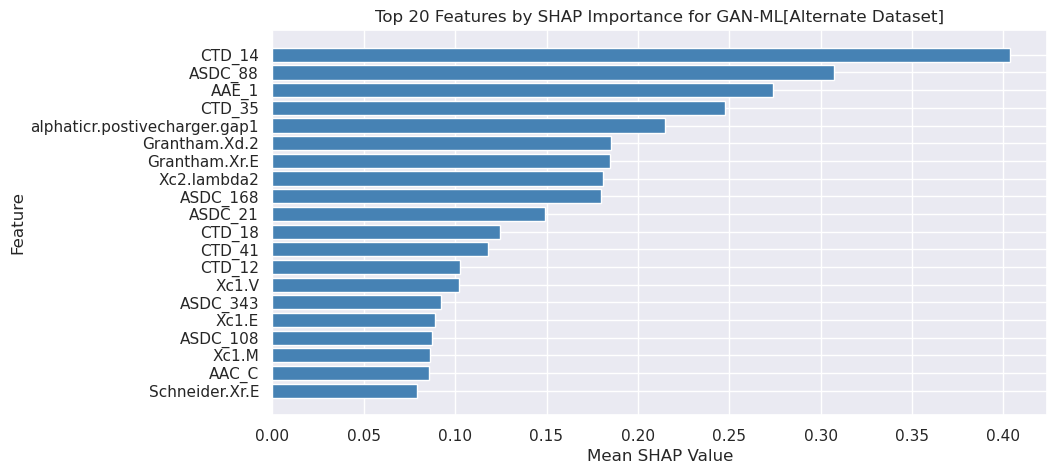

Processing SHAP for SVM


Using 1520 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/381 [00:00<?, ?it/s]

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Iterate through all models
for i in ml:
    print(f"Processing SHAP for {i}")
    
    model = eval(i)
    model.fit(X_train_std, y_train)
    
    # Use TreeExplainer for tree-based models, KernelExplainer for others
    if hasattr(model, "feature_importances_"):
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test_std)
    else:
        explainer = shap.KernelExplainer(model.predict, X_train_std)
        shap_values = explainer.shap_values(X_test_std)

    # Handling multi-class models (summing absolute SHAP values across classes)
    if isinstance(shap_values, list):  
        shap_values = np.abs(shap_values).mean(axis=0).sum(axis=0)
    else:
        shap_values = np.abs(shap_values).mean(axis=0)

    # Ensure feature names and SHAP values have the same length
    feature_importance_df = pd.DataFrame(
        {"Feature": fea[:len(shap_values)], "SHAP Value": shap_values}
    ).sort_values(by="SHAP Value", ascending=False)

    # Plot Top 20 Features
    plt.figure(figsize=(10, 5))
    plt.barh(feature_importance_df["Feature"][:20], feature_importance_df["SHAP Value"][:20], color="steelblue")
    plt.xlabel("Mean SHAP Value")
    plt.ylabel("Feature")
    plt.title(f"Top 20 Features by SHAP Importance for GAN-ML[Alternate Dataset]")
    plt.gca().invert_yaxis()  # Invert y-axis for highest importance at top
    plt.show()

In [ ]:
index = []
ALL_eval_test=pd.DataFrame()
for i in ml:
    eval_dict = []
    print('process_{}'.format(i))
    model = eval(i)
    model.fit(X_train_std,y_train)
    eval_dictionary = evaluate(X_test_std,y_test,model)
    eval_dict = eval_dict+[eval_dictionary]
    Evals = pd.DataFrame(eval_dict).T
    ALL_eval_test = pd.concat([ALL_eval_test,Evals],axis=1)
    index.append("{}".format(i))
ALL_eval_test.columns = index

In [ ]:
ALL_eval_test

In [ ]:
#Techniques for for downsampling and upsampling
#Downsampling
#i want to check does the model performans well for the independnet test

from imblearn.under_sampling import NearMiss,RandomUnderSampler,ClusterCentroids
from sklearn.linear_model import LogisticRegression

#Upsampling
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE

nm1 = NearMiss(version=1)
nm2 = NearMiss(version=2)
nm3 = NearMiss(version=3)
rus = RandomUnderSampler(random_state=seed,replacement=True)
cc = ClusterCentroids(random_state=seed)
smotee = SMOTEENN(random_state=10)
smote = SMOTE(random_state=seed)

In [ ]:
baml = ['nm1','nm2','nm3','rus','cc','smotee','smote']
ml_eval = pd.DataFrame()
index = []
for i in baml:
    for m in ml:
        print('process_{}'.format(m))
        X_resampled ,y_resampled = eval(i).fit_resample(X_train,y_train)
        evals = cv(eval(m),X_resampled,y_resampled)
        ml_eval = pd.concat([ml_eval,evals],axis=1)
        index.append("{}_{}".format(i,m))
ml_eval.columns = index
ml_eval.to_csv('results/balance_eval_AUC/different_balance_ml.csv')

In [ ]:
baml = ['nm1','nm2','nm3','rus','cc','smotee','smote']
ml_eval_test = []
index = []
for i in baml:
    for m in ml:
        print('process_{}'.format(m))
        X_resampled ,y_resampled = eval(i).fit_resample(X_train,y_train)
        eval(m).fit(X_resampled,y_resampled)
        evals = evaluate(X_test,y_test,eval(m))
        ml_eval_test = ml_eval_test + [evals]
        index.append("{}_{}".format(i,m))
ml_eval_test = pd.DataFrame(ml_eval_test).T
ml_eval_test.columns = index
ml_eval_test.to_csv('results/balance_eval_AUC/different_balance_ml_test.csv')

#this must guaranteer that the model doesn perform well on alternate dataset test data

In [ ]:
#normalizing the dataset using Standard Scalra and Min-max scalar
from sklearn.preprocessing import MinMaxScaler, StandardScaler
#Standarization and normalization of  train and test dataset
nms = MinMaxScaler()
X_train_norm = nms.fit_transform(X_train)
X_test_norm = nms.transform(X_test)
#STANDARIZATION
stdsc = StandardScaler(with_mean=False)
X_train_std = stdsc.fit_transform(X_train)
X_test_std = stdsc.transform(X_test)

In [ ]:
#Normalization ann standarization/min-max scaling
X_train_norm1 = pd.DataFrame(X_train_norm)
X_train_norm1.to_csv('data/train/X_train_norm.csv',index=False)
X_test_norm1 = pd.DataFrame(X_test_norm)
X_test_norm1.to_csv('data/test/X_test_norm.csv',index=False)

#Standarization
X_train_std1 = pd.DataFrame(X_train_std)
X_train_std1.to_csv('data/train/X_train_std.csv',index=False)
X_test_std1 = pd.DataFrame(X_test_std)
X_test_std1.to_csv('data/test/X_test_std.csv',index=False)

In [ ]:
X_train_norm = pd.read_csv('data/train/X_train_norm.csv').to_numpy()
X_test_norm = pd.read_csv('data/test/X_test_norm.csv').to_numpy()
X_train_std = pd.read_csv('data/train/X_train_std.csv').to_numpy()
X_test_std = pd.read_csv('data/test/X_test_std.csv').to_numpy()
y_train = pd.read_csv('data/train/y_train.csv').to_numpy()
y_test = pd.read_csv('data/test/y_test.csv').to_numpy()

In [ ]:
#normalization data and oversampling and undersamping
baml = ['nm1','nm2','nm3','rus','cc','smotee','smote']
ml_eval = pd.DataFrame()
index = []
for i in baml:
    for m in ml:
        print('process_{}'.format(m))
        X_resampled ,y_resampled = eval(i).fit_resample(X_train_norm,y_train)
        evals = cv(eval(m),X_resampled,y_resampled)
        ml_eval = pd.concat([ml_eval,evals],axis=1)
        index.append("{}_{}".format(i,m))
ml_eval.columns = index
ml_eval.to_csv('results/balance_eval_AUC/normal/different_balance_ml_norm.csv')

In [ ]:
#standarization data and oversampling and undersamping
baml = ['nm1','nm2','nm3','rus','cc','smotee','smote']
ml_eval = pd.DataFrame()
index = []
for i in baml:
    for m in ml:
        print('process_{}'.format(m))
        X_resampled ,y_resampled = eval(i).fit_resample(X_train_std,y_train)
        evals = cv(eval(m),X_resampled,y_resampled)
        ml_eval = pd.concat([ml_eval,evals],axis=1)
        index.append("{}_{}".format(i,m))
ml_eval.columns = index
ml_eval.to_csv('results/balance_eval_AUC/standard/different_balance_ml_std.csv')

In [ ]:
#standarization and effect in standarization in independent test data
baml = ['nm1','nm2','nm3','rus','cc','smotee','smote']
ml_eval_test = []
index = []
for i in baml:
    for m in ml:
        print('process_{}'.format(m))
        X_resampled ,y_resampled = eval(i).fit_resample(X_train_std,y_train)
        eval(m).fit(X_resampled,y_resampled)
        evals = evaluate(X_test_std,y_test,eval(m))
        ml_eval_test = ml_eval_test + [evals]
        index.append("{}_{}".format(i,m))
ml_eval_test = pd.DataFrame(ml_eval_test).T
ml_eval_test.columns = index
ml_eval_test.to_csv('results/balance_eval_AUC/standard/different_balance_ml_norm_test.csv')

In [ ]:
#normalization  and effect in independent test data
baml = ['nm1','nm2','nm3','rus','cc','smotee','smote']
ml_eval_test = []
index = []
for i in baml:
    for m in ml:
        print('process_{}'.format(m))
        X_resampled ,y_resampled = eval(i).fit_resample(X_train_norm,y_train)
        eval(m).fit(X_resampled,y_resampled)
        evals = evaluate(X_test_norm,y_test,eval(m))
        ml_eval_test = ml_eval_test + [evals]
        index.append("{}_{}".format(i,m))
ml_eval_test = pd.DataFrame(ml_eval_test).T
ml_eval_test.columns = index
ml_eval_test.to_csv('results/balance_eval_AUC/normal/different_balance_ml_norm_test.csv')